In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import flpoAgent 
import importlib 
import random 
from scipy.spatial.distance import cdist 
import createEnv 
from scipy.optimize import Bounds, LinearConstraint, minimize 
import supporting_functions 
from matplotlib.cm import get_cmap 

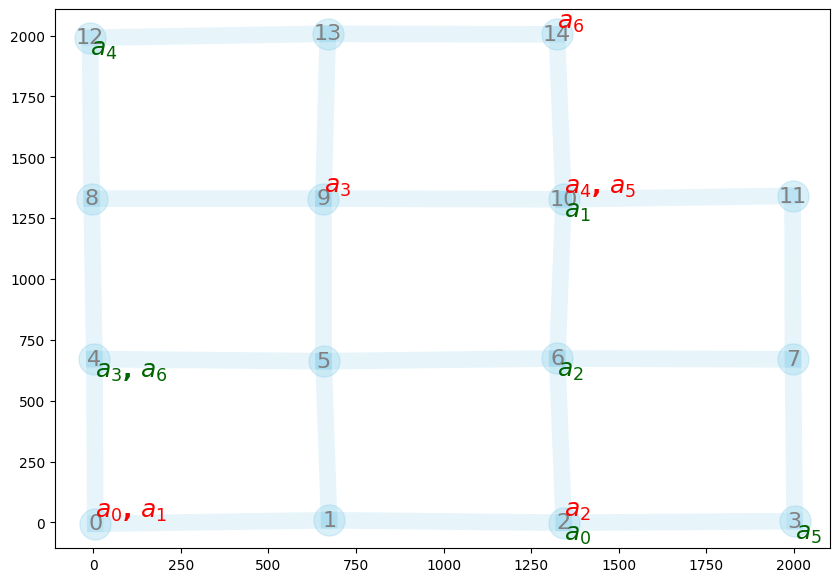

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 15
n_agents = 7
tolArray = np.random.uniform(10.0, 10.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':2000,
    'noise_factor':10
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# ellispoid cbf mode
ca_cbf_el = {
    'mode':'ellipse',
    'major_axis':1e-3*tolArray,
    'minor_axis':1e-4*tolArray,
    'degree':2
}

# linear cbf mode
ca_cbf_lin = {
    'mode':'linear',
    'eps':1e-4*tolArray,
    'eta':0
}

# cost mode options
cost_mode = 'sum' # 'slowest'
lm = 1 # for slowest

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params, 
    seed=13, 
    offset_energy=1,
    stagewiseCostCoeffs=np.array([0.1, 10.0, 0.1]),
    selfHop=0,
    ca_cbf=ca_cbf_lin,
    cost_mode=cost_mode,
    lm = lm,
    filter_wp_thresh=1e-10,
    printFlag=False)

# mars visualization 
cmap = plt.get_cmap('tab20') 
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))} 
createEnv.plotNetwork(mars=mars, figuresize=(10,7), routes=[], agent_colors=agent_colors, showEdgeLength=False) 

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [3]:
beta_min = 1e-3
beta_max = 1e3
beta_grow = 3
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow

T0 = mars.sched_mat
# T0 = np.ones((mars.n_agents, mars.n_waypoints))
# for i in range(mars.n_agents):
#     if i > 0:
#         T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0, 5, mars.tolArray.shape)
# T0 = np.random.uniform(0, 10, (mars.n_agents, mars.n_waypoints))
V0 = mars.speed_vec

optimizer_cbf_clf = {
    'name':'cbf_clf',
    'dt_init':0.05,
    'dt_min':1e-5,
    'dt_max':0.05,
    'Tf':10,
    'gamma':1,
    'alpha_s':100,
    'alpha_c':10,
    'alpha_r':100,
    'alpha_q':100,
    'p':1,
    'stop_tol':0.00001,
    'stop_tol_weight':np.array([0, 0, 1, 0]),
    'verbose':0
}

optimizer_slsqp = {
    'name':'SLSQP',
    'stop_tol':0.01,
    'disp':False
}

optimizers = [optimizer_cbf_clf, optimizer_slsqp]


In [4]:
mars.start_times

array([40.82807639,  3.98600589,  8.58376488, 41.90745161, 28.20801394,
       17.48911068,  7.25014814])

In [5]:
mars.ca_cbf = ca_cbf_el
cbf_mode = mars.ca_cbf['mode']
active_waypoints = None #range(mars.n_waypoints)
print(f'mars cbf mode: {cbf_mode}')
print(beta_arr) 

for optim in optimizers:
    name = optim['name']
    print(f'--------------------------------------') 
    print(f'       solving using {name}           ') 
    print(f'--------------------------------------') 

    T, V, F, Pb_a = mars.anneal( 
        beta_arr, 
        T0, 
        V0, 
        active_waypoints=active_waypoints, 
        optimizer=optim, 
        annealPrint=True) 
    optim['T_final'] = T 
    optim['V_final'] = V 
    optim['F_final'] = F 
    optim['Pb_a_final'] = Pb_a 



mars cbf mode: ellipse
[0.001, 0.003, 0.009000000000000001, 0.027000000000000003, 0.08100000000000002, 0.24300000000000005, 0.7290000000000001, 2.1870000000000003, 6.561000000000001, 19.683000000000003, 59.04900000000001, 177.14700000000002, 531.441]
--------------------------------------
       solving using cbf_clf           
--------------------------------------
a:0.000	b:0.001
None type returned inside get_CBF_control!
None encountered from get_CBF_control... returning previous iterate!

beta: 1.0000e-03	cost: 0.000	tolb: 0.000e+00	n_active_waypoints:15	tol_mag:10.00
a:4.039	b:3.962

beta: 3.0000e-03	cost: 1004.468	tolb: 9.582e-06	n_active_waypoints:13	tol_mag:10.00
a:15.533	b:7.216

beta: 9.0000e-03	cost: 349.731	tolb: 8.847e-06	n_active_waypoints:8	tol_mag:10.00
a:33.230	b:8.531

beta: 2.7000e-02	cost: 131.348	tolb: 7.154e-06	n_active_waypoints:7	tol_mag:10.00
a:55.410	b:9.115

beta: 8.1000e-02	cost: 59.663	tolb: 8.454e-06	n_active_waypoints:7	tol_mag:10.00
a:80.256	b:9.415

bet

/Users/dhananjaytiwari/Library/Python/3.9/lib/python/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



beta: 6.5610e+00	cost: 24.673	tolb: 9.033e-06	n_active_waypoints:7	tol_mag:10.00
a:168.977	b:9.973

beta: 1.9683e+01	cost: 25.399	tolb: 6.516e-06	n_active_waypoints:7	tol_mag:10.00
a:200.300	b:9.981

beta: 5.9049e+01	cost: 25.932	tolb: 9.707e-06	n_active_waypoints:7	tol_mag:10.00
a:228.667	b:9.985

beta: 1.7715e+02	cost: 26.460	tolb: 5.655e-06	n_active_waypoints:7	tol_mag:10.00
a:253.604	b:9.989

beta: 5.3144e+02	cost: 26.885	tolb: 9.410e-06	n_active_waypoints:7	tol_mag:10.00
--------------------------------------
       solving using SLSQP           
--------------------------------------
a:0.000	b:0.001

beta: 1.0000e-03	cost: 2425.682	tol_mag:10.00
a:4.039	b:3.962

beta: 3.0000e-03	cost: 846.870	tol_mag:10.00
a:15.533	b:7.216

beta: 9.0000e-03	cost: 297.367	tol_mag:10.00
a:33.230	b:8.531

beta: 2.7000e-02	cost: 119.687	tol_mag:10.00
a:55.410	b:9.115

beta: 8.1000e-02	cost: 56.204	tol_mag:10.00
a:80.256	b:9.415

beta: 2.4300e-01	cost: 35.011	tol_mag:10.00
a:106.142	b:9.586

beta: 7.

--------------------------------
       cbf_clf results           
--------------------------------
+----+-------------------+---------------------------------+-------+--------+-------+-----------------------+-------+
| A  |         R         |                T                |   V   | V Mean | V Max |         V Lim         | Cost  |
+----+-------------------+---------------------------------+-------+--------+-------+-----------------------+-------+
| v0 |     [2, 1, 0]     |       [55.79 64.86 73.92]       | 73.73 | 73.76  | 73.77 |     [ 0.78 73.73]     | 38.83 |
| v1 | [10, 9, 8, 4, 0]  | [ 4.56 13.5  22.19 30.95 39.76] | 76.80 | 76.22  | 76.76 |     [ 0.65 76.8 ]     | 30.91 |
| v2 |      [6, 2]       |          [ 8.58 17.74]          | 72.56 | 73.75  | 73.75 |     [ 0.72 72.56]     | 8.88  |
| v3 |     [4, 8, 9]     |       [50.74 59.8  68.81]       | 73.48 | 73.12  | 73.50 | [4.000e-02 7.348e+01] | 24.05 |
| v4 |  [12, 13, 9, 10]  |    [32.48 42.22 51.92 61.7 ]    | 70.09 | 69.87

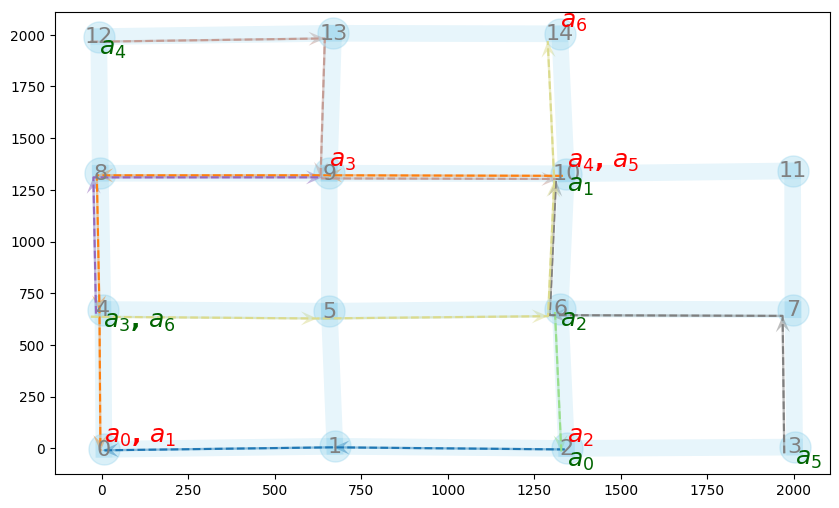

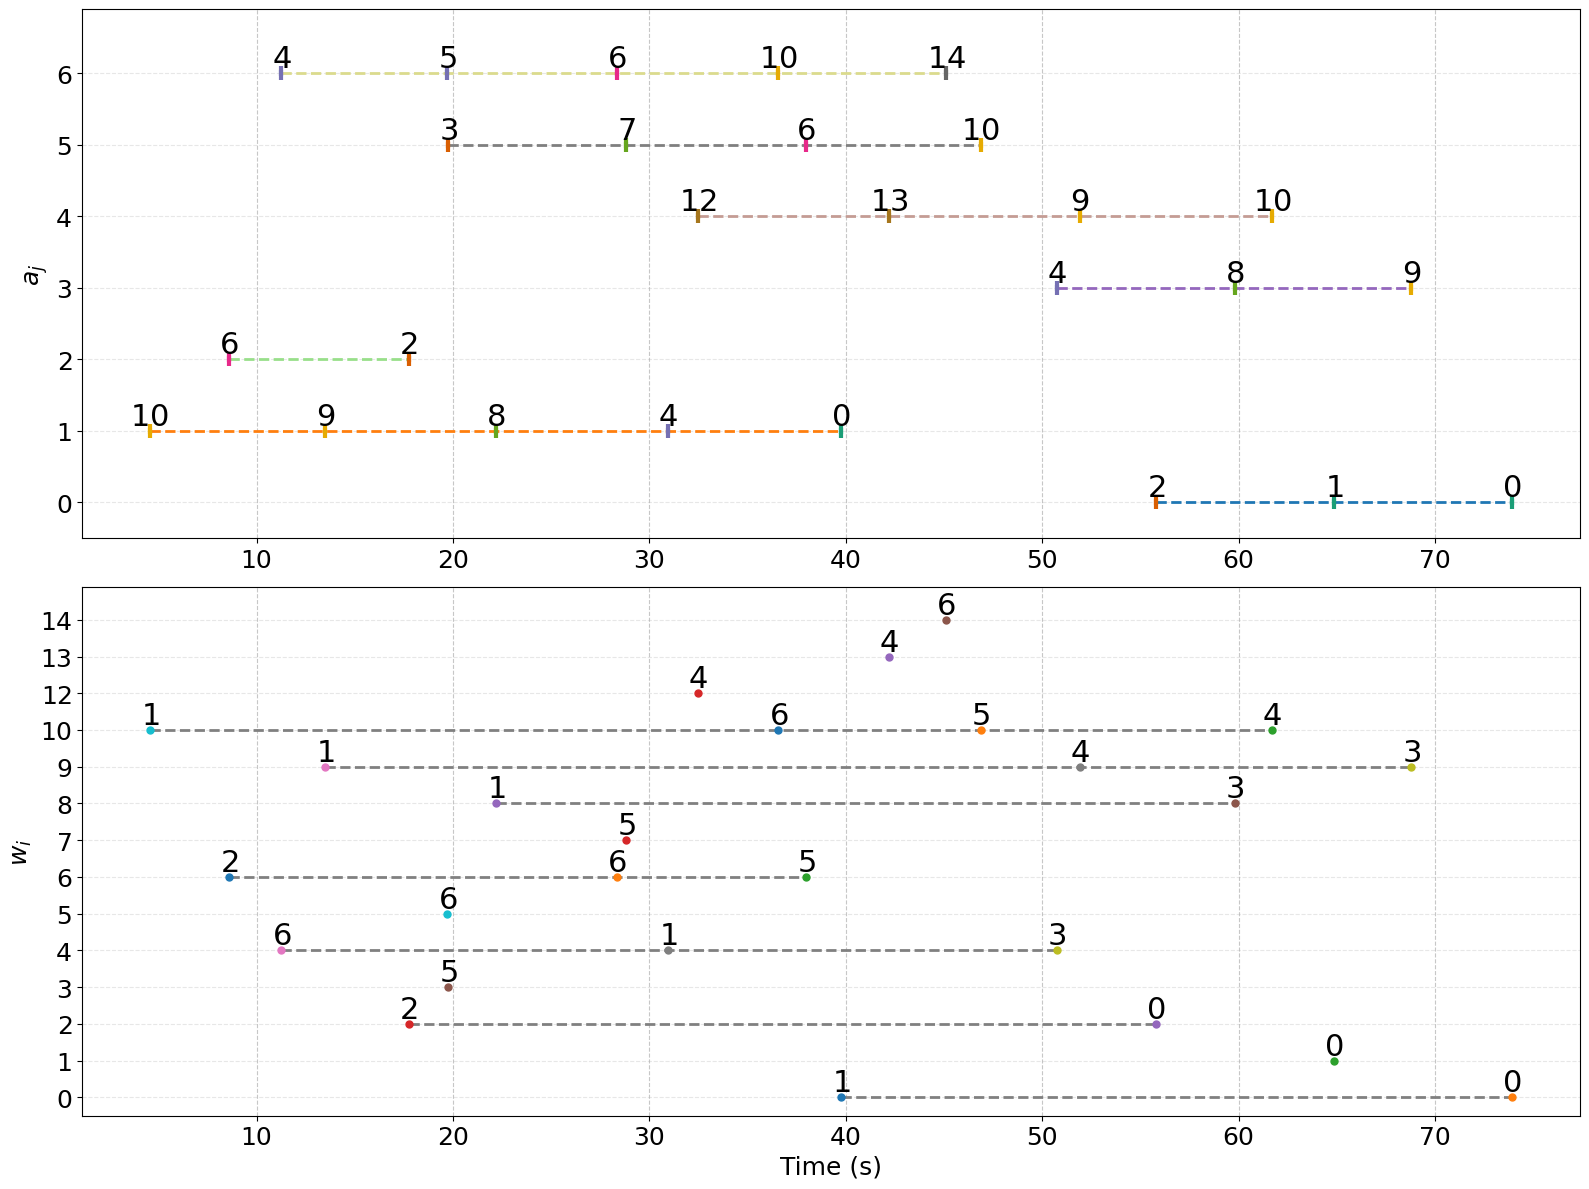

--------------------------------
       SLSQP results           
--------------------------------
+----+-------------------+---------------------------------+-------+--------+-------+-----------------------+-------+
| A  |         R         |                T                |   V   | V Mean | V Max |         V Lim         | Cost  |
+----+-------------------+---------------------------------+-------+--------+-------+-----------------------+-------+
| v0 |     [2, 1, 0]     |       [55.78 64.85 73.9 ]       | 73.73 | 73.81  | 73.82 |     [ 0.78 73.73]     | 38.82 |
| v1 | [10, 9, 8, 4, 0]  | [ 3.99 15.08 25.9  36.7  47.55] | 62.28 | 61.58  | 62.30 |     [ 0.65 76.8 ]     | 47.31 |
| v2 |      [6, 2]       |          [ 8.58 17.73]          | 72.56 | 73.78  | 73.78 |     [ 0.72 72.56]     | 8.89  |
| v3 |     [4, 5, 9]     |       [64.84 74.   83.12]       | 73.28 | 72.36  | 73.30 | [4.000e-02 7.348e+01] | 69.41 |
| v4 |  [12, 13, 9, 10]  |    [42.22 52.25 62.26 72.24]    | 68.69 | 67.99  

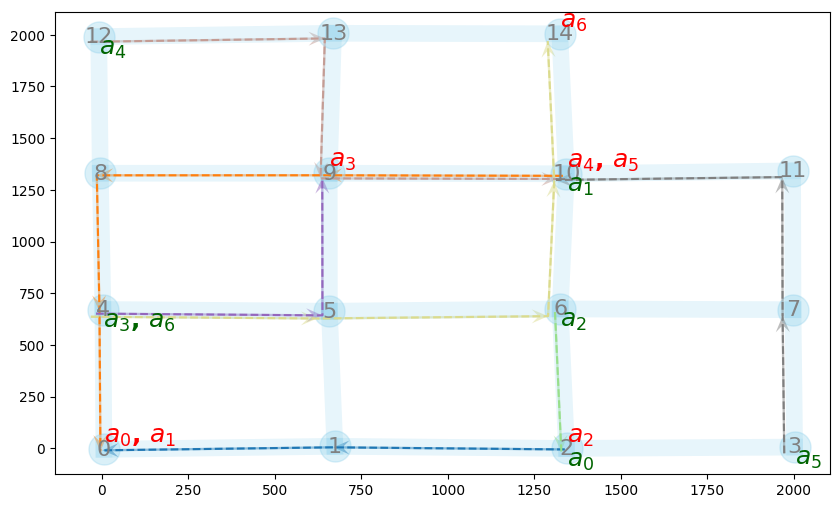

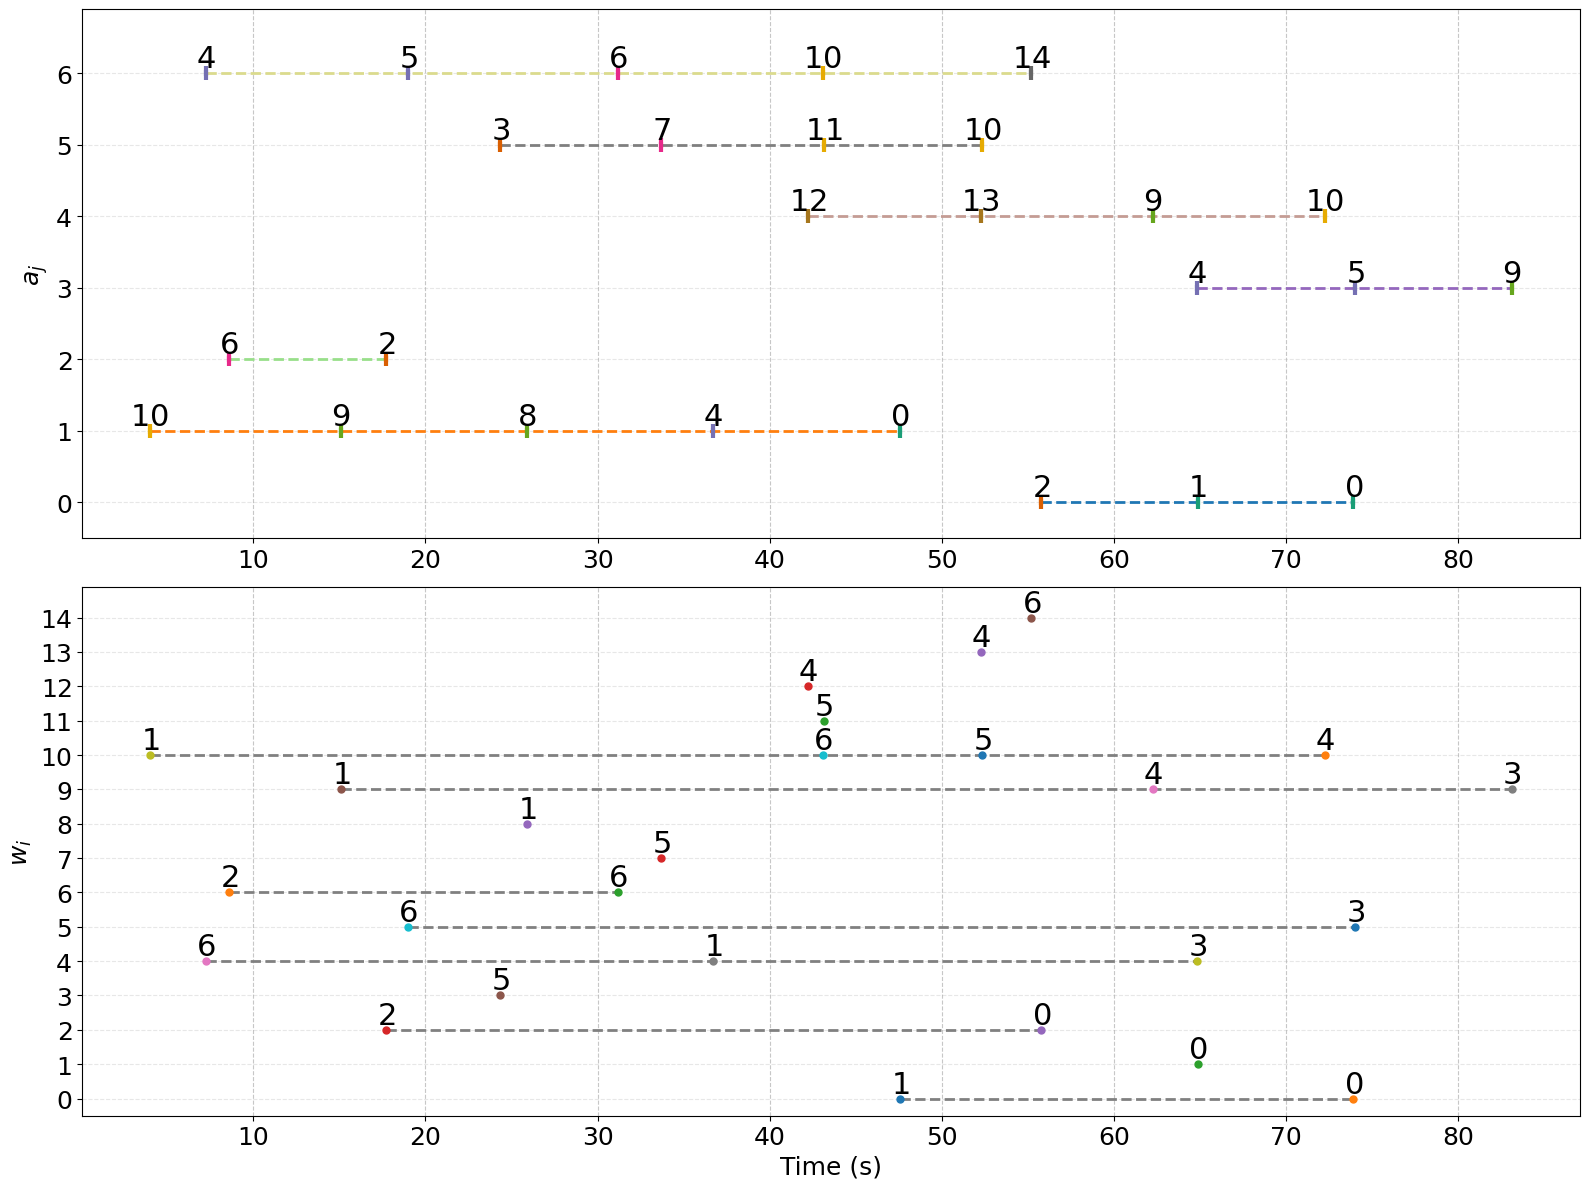

In [6]:
for optim in optimizers:
    name = optim['name']
    mars.sched_mat = optim['T_final']
    mars.speed_vec = optim['V_final']
    Pb_a = optim['Pb_a_final']

    print(f'--------------------------------')
    print(f'       {name} results           ')
    print(f'--------------------------------')

    agent_routes, agent_schedules = createEnv.show_solution_table( 
        mars, 
        Pb_a, 
        beta=beta_arr[-1], 
        printRoutes=True)
        
    createEnv.plotNetwork(
        mars=mars, 
        figuresize=(10,6), 
        routes=agent_routes, 
        agent_colors=agent_colors, 
        showEdgeLength=False) 

    reach_mat = mars.calc_agent_reach_mat_v1(
        mars.sched_mat,
        mars.speed_vec,
        beta=beta_arr[-1]
    )

    association_mat = np.ones(shape=reach_mat.shape)
    association_mat[reach_mat <= 1e-10] = 0.0

    createEnv.plot_waypoint_agent_schedules(
        agent_routes,
        agent_schedules,
        mars.sched_mat,
        association_mat,
        mars.process_T,
        agent_colors,
        figuresize=(16,12)
    )

